# Data Visualisation

In [14]:
import pandas as pd

data = pd.read_csv("../data/simulated_data.csv")

## Python-Style Graphs

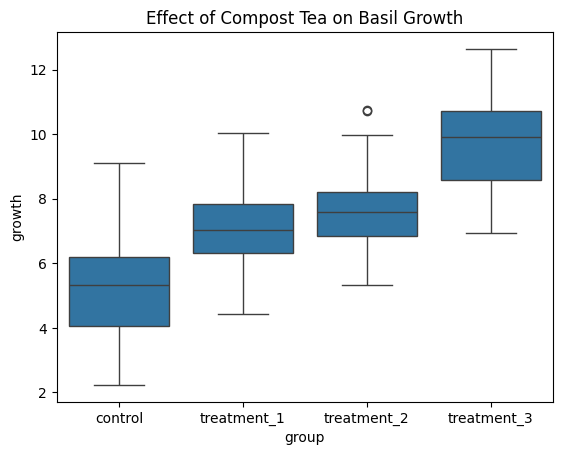

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="group", y="growth", data=data)
plt.title("Effect of Compost Tea on Basil Growth")
plt.show()

Text(0.5, 1.0, 'Distributions of growth amount by treatment group')

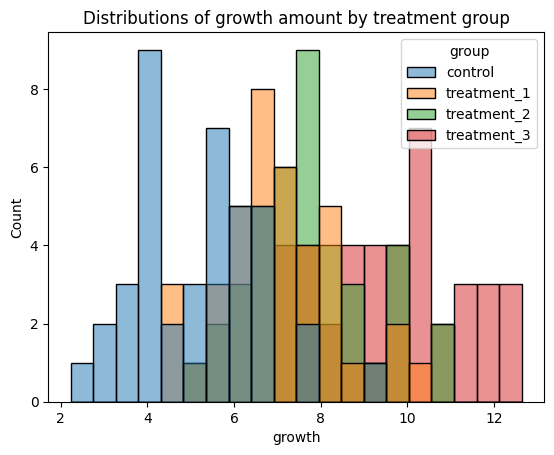

In [22]:
sns.histplot(data=data, x="growth", hue="group", bins=20)
plt.title("Distributions of growth amount by treatment group")

Text(0.5, 0, 'Growth (cm)')

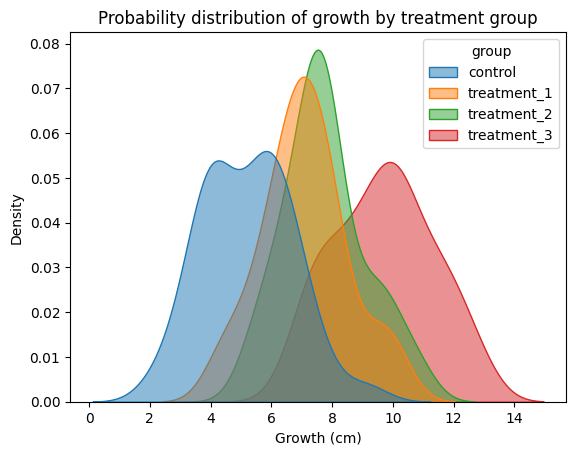

In [98]:
sns.kdeplot(
    data=data,
    x="growth",
    hue="group",
    fill=True,
    alpha=0.5
)
plt.title("Probability distribution of growth by treatment group")
plt.xlabel("Growth (cm)")

<Axes: xlabel='time', ylabel='height'>

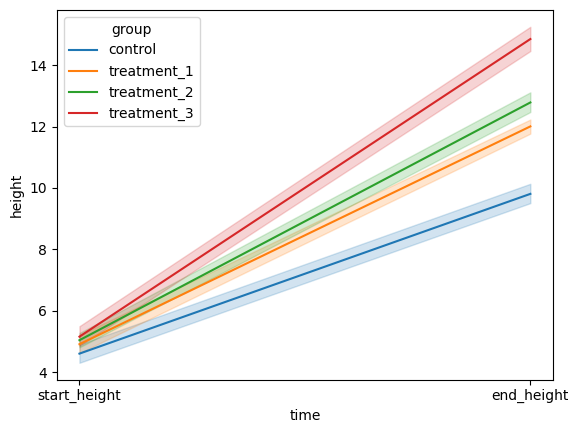

In [ ]:
long_df = data.melt(
    id_vars=["plant_id", "group"],
    value_vars=["start_height", "end_height"],
    var_name="time",
    value_name="height"
).sort_values("plant_id")

sns.lineplot(data=long_df, x="time", y="height", hue="group")

## R-Style Graphs

In [115]:
from plotnine import (
    aes,
    annotate,
    arrow,
    geom_boxplot,
    geom_density,
    geom_histogram,
    geom_violin,
    ggplot,
    labs
)

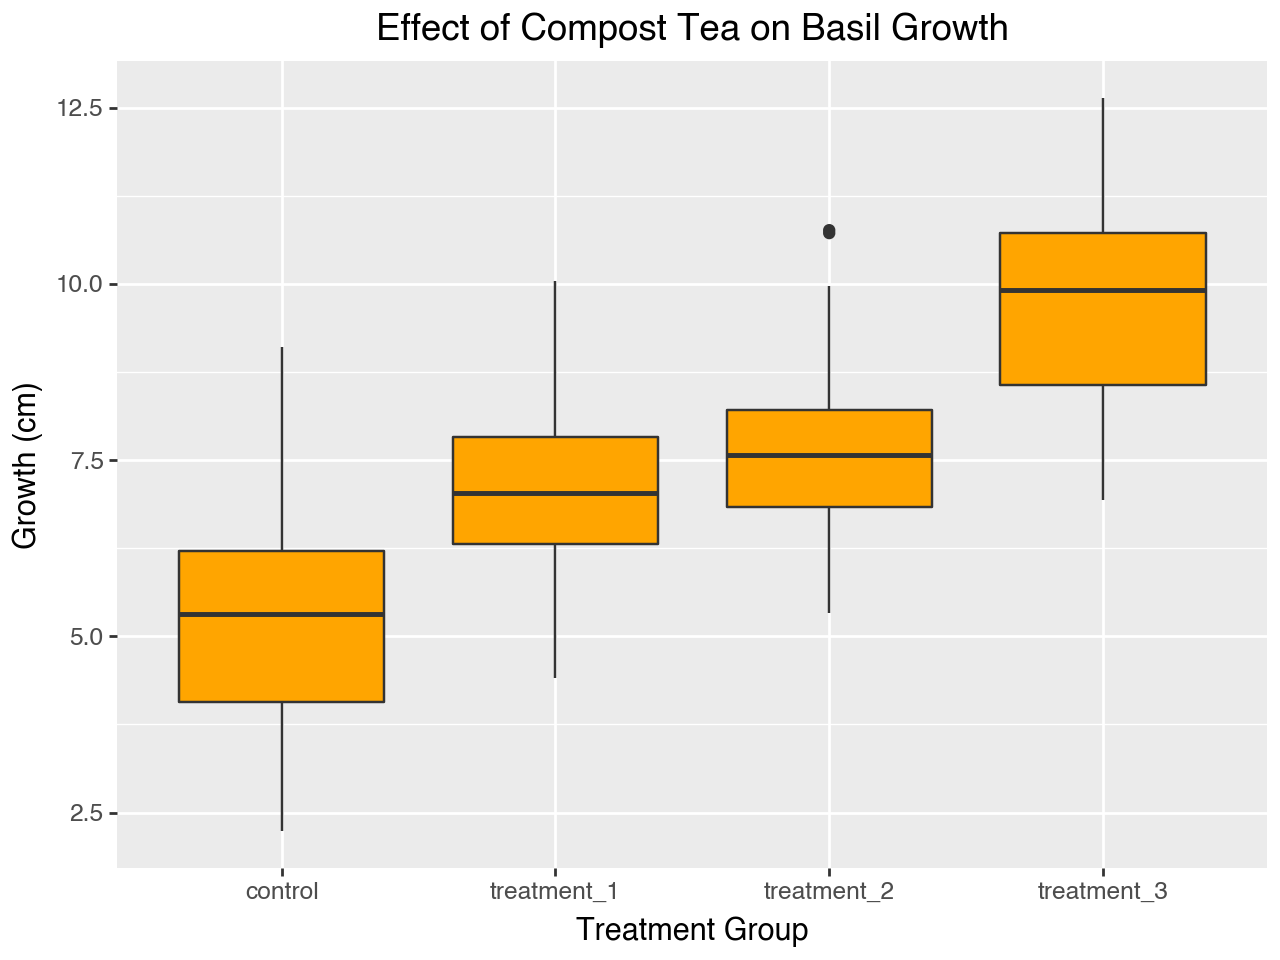

In [95]:
(
    ggplot(data, aes(x="group", y="growth"))
    + geom_boxplot(fill="orange")
    + labs(
        title = "Effect of Compost Tea on Basil Growth",
        x = "Treatment Group",
        y = "Growth (cm)",
    )
)


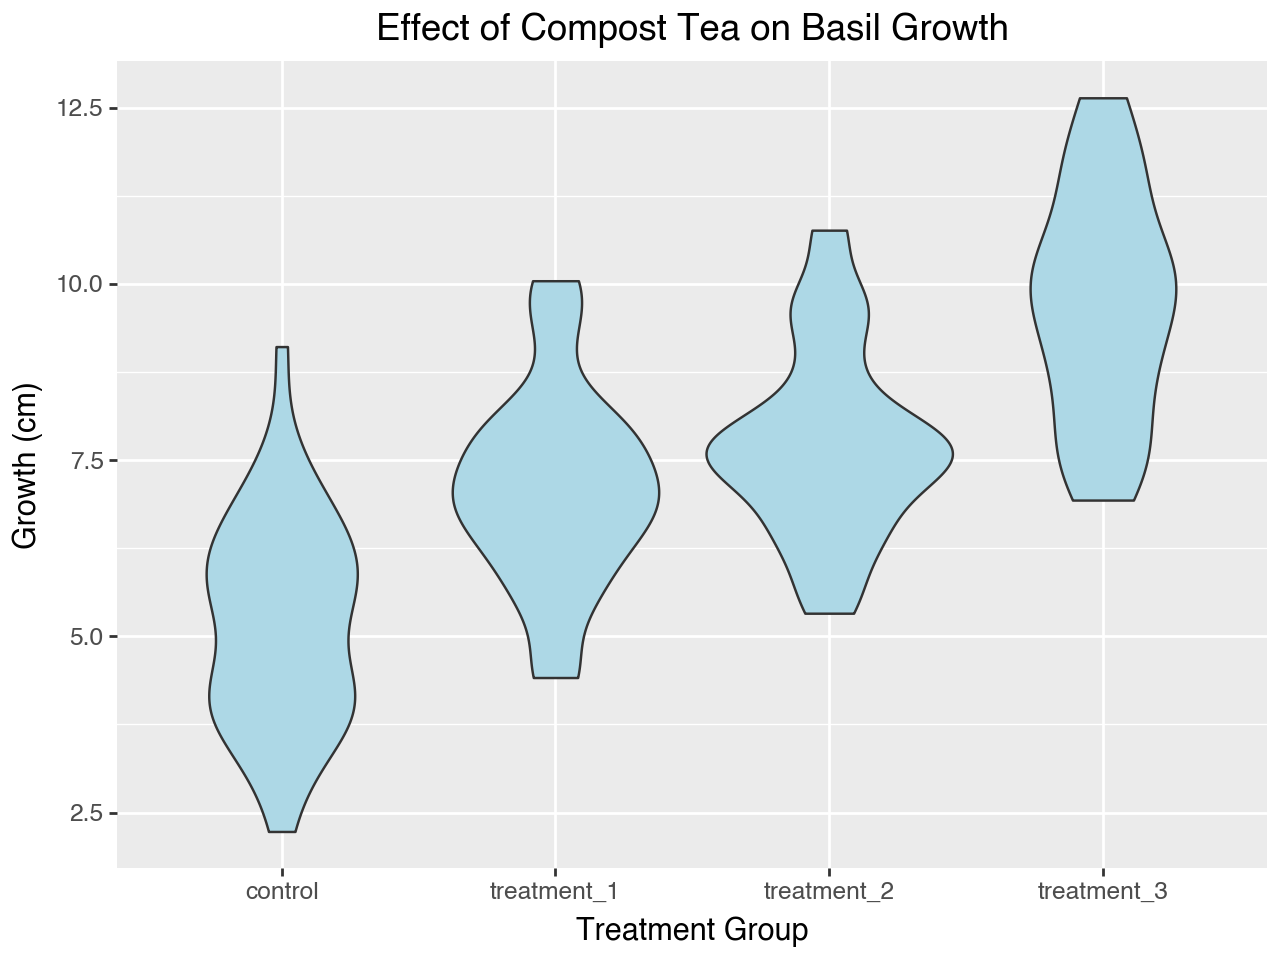

In [96]:
(
    ggplot(data, aes(x="group", y="growth"))
    + geom_violin(fill="lightblue")
    + labs(
        title = "Effect of Compost Tea on Basil Growth",
        x = "Treatment Group",
        y = "Growth (cm)",
    )
)

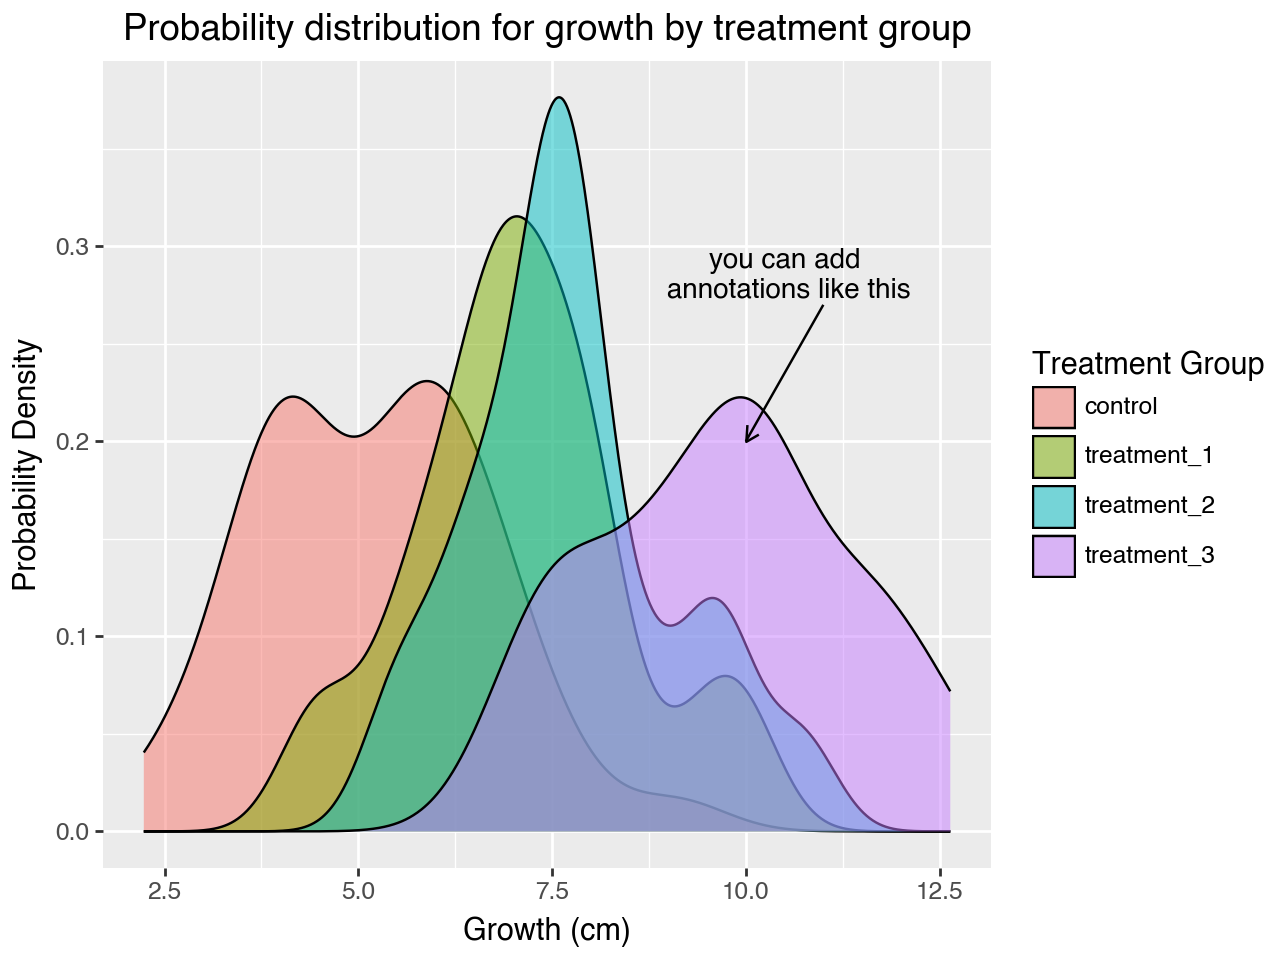

In [129]:
plot = (
    ggplot(data, aes(x="growth", fill="group"))
    + geom_density(alpha=0.5)
    + labs(
        title="Probability distribution for growth by treatment group",
        x="Growth (cm)",
        y="Probability Density",
        fill="Treatment Group",
    )
    + annotate(
        "text",
        x=11.5,
        y=0.285,
        label=f"you can add\n annotations like this",
        # color="blue",
        size=10,
        nudge_x=-1,
    )
    + annotate(
        "segment",
        x=11,
        y=0.27,
        xend=10,
        yend=0.2,
        # color="red",
        arrow=arrow(length=0.1),
    )
)
plot